<a href="https://colab.research.google.com/github/BlackHole3344/FineTune/blob/main/CSM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install datasets



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 23.1 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.2 requires fsspec==2025.3.2, but you have fsspec 2024.12.0 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which

In [2]:
from datasets import load_dataset

In [3]:
ds = load_dataset("m-aliabbas/idrak_timit_subsample1" , split = "train")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


dataset_infos.json:   0%|          | 0.00/1.15k [00:00<?, ?B/s]

(…)-00000-of-00001-aeb35d2d506d38bf.parquet:   0%|          | 0.00/29.5M [00:00<?, ?B/s]

(…)-00000-of-00001-0dca1a897ce597dd.parquet:   0%|          | 0.00/1.88M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1296 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/324 [00:00<?, ? examples/s]

In [4]:
ds

Dataset({
    features: ['audio', 'transcription'],
    num_rows: 1296
})

In [ ]:
print(len(ds["audio"][0].get("array")))
example_clip = ds["audio"][0].get("array")

35840


In [ ]:
ds["transcription"][0]

'don t ask me to carry an oily rag like that'

In [ ]:
example_clip

array([3.05175781e-05, 0.00000000e+00, 3.05175781e-05, ...,
       0.00000000e+00, 3.05175781e-05, 1.22070312e-04])

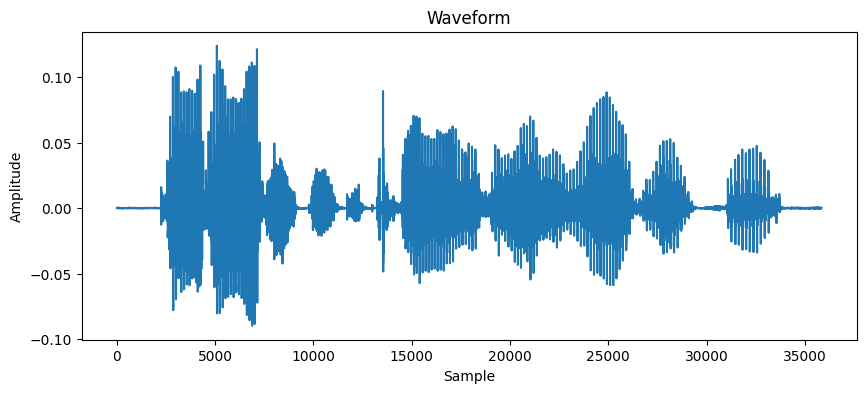

In [ ]:

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.plot(example_clip)
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.title("Waveform")
plt.show()


In [30]:
import numpy as np
from scipy.io import wavfile
import matplotlib.pyplot as plt
from IPython.display import Audio
import soundfile as sf  # Alternative to scipy for saving audio files

def convert_array_to_audio(amplitude_array, sample_rate=16000, filename='output.wav', normalize=True):
    """
    Convert an amplitude array to an audio file and return an Audio object for playback

    Parameters:
    -----------
    amplitude_array : numpy.ndarray
        The amplitude values of the audio signal
    sample_rate : int
        Sample rate in Hz, default is 16000 (typical for speech)
    filename : str
        Output filename for the WAV file
    normalize : bool
        Whether to normalize the amplitude values to avoid clipping

    Returns:
    --------
    IPython.display.Audio
        Audio object that can be played in a Jupyter notebook
    """
    # Convert to numpy array if it's not already

    if not isinstance(amplitude_array, np.ndarray):
      amplitude_array = np.array(amplitude_array)

    if normalize:
        max_val = np.max(np.abs(amplitude_array))
        if max_val > 0:
            amplitude_array = amplitude_array / max_val


    audio_16bit = (amplitude_array * 32767).astype(np.int16)


    wavfile.write(filename, sample_rate, audio_16bit)


    return Audio(data=audio_16bit, rate=sample_rate)

def plot_waveform(amplitude_array, sample_rate=16000, seconds=None , title="Audio Waveform" , start_time = 0 ,end_time = None):
    full_duration = len(amplitude_array) / sample_rate
    time = np.arange(len(amplitude_array)) / sample_rate

    # Handle the 'seconds' parameter for backward compatibility
    if seconds is not None:
        if end_time is None:
            end_time = min(start_time + seconds, full_duration)
        else:
            print("Warning: Both 'seconds' and 'end_time' parameters provided. Using 'end_time'.")

    # Set default end_time if not specified
    if end_time is None:
        end_time = full_duration

    # Ensure start and end times are within valid range
    start_time = max(0, min(start_time, full_duration))
    end_time = max(start_time, min(end_time, full_duration))

    # Convert times to sample indices
    start_sample = int(start_time * sample_rate)
    end_sample = int(end_time * sample_rate)

    # Plot full waveform
    plt.figure(figsize=(12, 4))
    plt.plot(time, amplitude_array)
    # Add a rectangle to show the zoom region
    if start_time > 0 or end_time < full_duration:
        y_min, y_max = plt.ylim()
        height = y_max - y_min
        plt.axvspan(start_time, end_time, alpha=0.2, color='red')
    plt.title(f"{title} (Full Duration: {full_duration:.2f} seconds)")
    plt.xlabel('Time (seconds)')
    plt.ylabel('Amplitude')
    plt.grid(True)
    plt.show()

    # Plot zoomed view
    plt.figure(figsize=(12, 4))
    plt.plot(time[start_sample:end_sample], amplitude_array[start_sample:end_sample])
    plt.title(f"{title} (Zoomed: {start_time:.2f}s to {end_time:.2f}s)")
    plt.xlabel('Time (seconds)')
    plt.ylabel('Amplitude')
    plt.grid(True)
    plt.show()

    # If requested, show a detailed view of a short segment
    if (end_time - start_time) > 1.0:
        detailed_end = min(start_time + 0.5, end_time)
        detailed_start_sample = int(start_time * sample_rate)
        detailed_end_sample = int(detailed_end * sample_rate)

        plt.figure(figsize=(12, 4))
        plt.plot(time[detailed_start_sample:detailed_end_sample],
                 amplitude_array[detailed_start_sample:detailed_end_sample])
        plt.title(f"{title} (Detailed View: {start_time:.2f}s to {detailed_end:.2f}s)")
        plt.xlabel('Time (seconds)')
        plt.ylabel('Amplitude')
        plt.grid(True)
        plt.show()

def analyze_audio(amplitude_array, sample_rate=16000):
    """
    Analyze the audio signal and print statistics

    Parameters:
    -----------
    amplitude_array : numpy.ndarray
        The amplitude values of the audio signal
    sample_rate : int
        Sample rate in Hz
    """
    duration = len(amplitude_array) / sample_rate

    print(f"Audio Statistics:")
    print(f"- Duration: {duration:.2f} seconds")
    print(f"- Sample Rate: {sample_rate} Hz")
    print(f"- Number of Samples: {len(amplitude_array)}")
    print(f"- Min Amplitude: {np.min(amplitude_array)}")
    print(f"- Max Amplitude: {np.max(amplitude_array)}")
    print(f"- Mean Amplitude: {np.mean(amplitude_array)}")
    print(f"- RMS Amplitude: {np.sqrt(np.mean(np.square(amplitude_array)))}")

    # Check for potential clipping
    if np.max(np.abs(amplitude_array)) > 0.99:
        print("WARNING: Audio might be clipping. Consider normalizing.")

# Example usage:
"""
# Example 1: Using your actual amplitude array
amplitude_array = np.array([3.05175781e-05, 0.00000000e+00, 3.05175781e-05, ...])
sample_rate = 16000  # Set this to the correct sample rate for your audio

# Visualize the waveform
plot_waveform(amplitude_array, sample_rate)

# Analyze the audio
analyze_audio(amplitude_array, sample_rate)

# Convert to audio file and get player
audio = convert_array_to_audio(amplitude_array, sample_rate, 'my_audio.wav')

# In a Jupyter notebook, you can display the audio player:
display(audio)
"""

# Example 2: Creating a test tone
"""
# Create a 3-second test tone
sample_rate = 16000
duration = 3
t = np.linspace(0, duration, int(sample_rate * duration))
frequency = 440  # A440 note
amplitude = 0.5 * np.sin(2 * np.pi * frequency * t)

# Add some fade in/out to avoid clicks
fade_samples = int(0.1 * sample_rate)
fade_in = np.linspace(0, 1, fade_samples)
fade_out = np.linspace(1, 0, fade_samples)
amplitude[:fade_samples] *= fade_in
amplitude[-fade_samples:] *= fade_out

# Convert to audio
audio = convert_array_to_audio(amplitude, sample_rate, 'test_tone.wav')
display(audio)
"""

"\n# Create a 3-second test tone\nsample_rate = 16000\nduration = 3\nt = np.linspace(0, duration, int(sample_rate * duration))\nfrequency = 440  # A440 note\namplitude = 0.5 * np.sin(2 * np.pi * frequency * t)\n\n# Add some fade in/out to avoid clicks\nfade_samples = int(0.1 * sample_rate)\nfade_in = np.linspace(0, 1, fade_samples)\nfade_out = np.linspace(1, 0, fade_samples)\namplitude[:fade_samples] *= fade_in\namplitude[-fade_samples:] *= fade_out\n\n# Convert to audio\naudio = convert_array_to_audio(amplitude, sample_rate, 'test_tone.wav')\ndisplay(audio)\n"

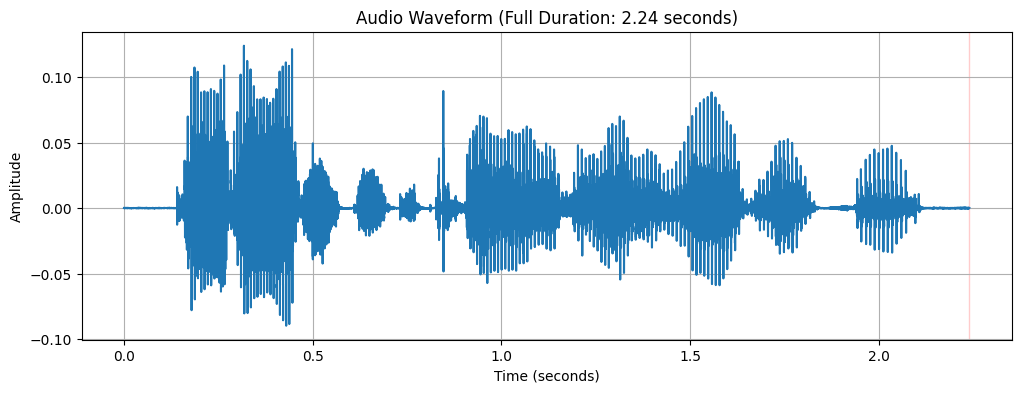

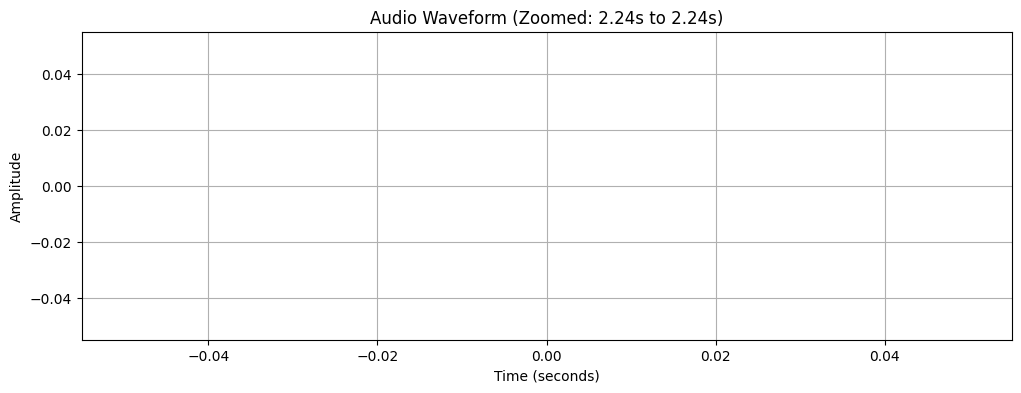

In [31]:
clip_array = np.array(example_clip)
sample_rate = 16000

plot_waveform(clip_array, sample_rate , start_time=500 , end_time=2000)

In [19]:
analyze_audio(clip_array, sample_rate)

Audio Statistics:
- Duration: 2.24 seconds
- Sample Rate: 16000 Hz
- Number of Samples: 35840
- Min Amplitude: -0.08984375
- Max Amplitude: 0.123992919921875
- Mean Amplitude: -1.3174329485212054e-05
- RMS Amplitude: 0.014856694436240436


In [20]:
convert_array_to_audio(clip_array, sample_rate, 'my_audio.wav')

In [4]:

####character level tokenizer
import string
class CharacterTokenizer:
    def __init__(self):
        self.char_map = {
            '<PAD>': 0, '<BOS>': 1, '<EOS>': 2, '<UNK>': 3,
            ' ': 4
        }
        for i, char in enumerate(string.ascii_uppercase):
            self.char_map[char] = i + 5


        self.id_map = {v: k for k, v in self.char_map.items()}

    def encode(self, text, add_special_tokens=True):

        if add_special_tokens:
            token_ids = [self.char_map['<BOS>']]
        else:
            token_ids = []

        for char in text.upper():
            token_ids.append(self.char_map.get(char, self.char_map['<UNK>']))

        if add_special_tokens:
            token_ids.append(self.char_map['<EOS>'])

        return token_ids

    def decode(self, token_ids, remove_special_tokens=True):
        text = ""
        for token_id in token_ids:
            char = self.id_map[token_id]
            if remove_special_tokens and char in ['<PAD>', '<BOS>', '<EOS>', '<UNK>']:
                continue
            text += char
        return text

In [5]:
tokenizer = CharacterTokenizer()

inputs_ids = tokenizer.encode("Hello World")
print(len("Hello World"))
print(inputs_ids)
print(tokenizer.decode(inputs_ids))

11
[1, 12, 9, 16, 16, 19, 4, 27, 19, 22, 16, 8, 2]
HELLO WORLD


In [26]:
def collate_fn(batch, tokenizer=None):
    """
    Collate function for audio data with proper error handling

    Args:
        batch: List of dictionary items with 'audio' and 'transcript' keys
        tokenizer: CharacterTokenizer instance (if None, creates a new one)
    """
    if tokenizer is None:
        tokenizer = CharacterTokenizer()

    # Check if batch is empty
    if not batch:
        return None

    # Sort by audio length (descending)
    batch.sort(key=lambda x: len(x["audio"]["array"]), reverse=True)

    # Get maximum audio length
    max_audio_len = len(batch[0]["audio"]["array"])

    # Tokenize all transcripts once
    tokenized_transcripts = [tokenizer.encode(entry["transcription"]) for entry in batch]

    # Get maximum tokenized transcript length
    max_transcript_len = max(len(tokens) for tokens in tokenized_transcripts)

    # Track original lengths
    audio_lengths = torch.LongTensor([len(entry["audio"]["array"]) for entry in batch])
    transcript_lengths = torch.LongTensor([len(tokens) for tokens in tokenized_transcripts])

    # Pad audio (as float tensors)
    padded_audio = torch.zeros(len(batch), max_audio_len, dtype=torch.float32)
    for i, sample in enumerate(batch):
        audio_array = sample["audio"]["array"]
        # Convert numpy array to tensor
        audio_tensor = torch.tensor(audio_array, dtype=torch.float32)
        padded_audio[i, :len(audio_array)] = audio_tensor

    # Pad tokenized transcripts
    padded_transcripts = torch.full((len(batch), max_transcript_len),
                                  fill_value=tokenizer.char_map['<PAD>'],
                                  dtype=torch.long)
    for i, tokens in enumerate(tokenized_transcripts):
        padded_transcripts[i, :len(tokens)] = torch.tensor(tokens, dtype=torch.long)

    return {
        "audio": padded_audio,
        "audio_lengths": audio_lengths,
        "transcript": padded_transcripts,
        "transcript_lengths": transcript_lengths,
        "sampling_rate": batch[0]["audio"]["sampling_rate"]  # Include sampling rate
    }


In [35]:
#######DataLoader
from torch.utils.data import Dataset , DataLoader
import torch


class AudioDataset :

  def __init__(self , dataset , batch_size : int = 32 ) :
    self.dataset = dataset
    self.batch_size = batch_size
    self.tokenizer = CharacterTokenizer()

  def _len_(self) :
    return len(self.dataset)

  def _getitem_(self , id : int ):
    item = self.dataset[id]
    audio_tensor = torch.from_numpy(item["audio"]["array"]).to(float)
    transcript = item["transcription"].upper()
    return {"audio" : audio_tensor , "transcript" : transcript}


  def get_batch(self , batch_size : int = 32 , num_workers : int = 4) :

    return DataLoader(self.dataset , batch_size = batch_size , collate_fn=collate_fn)





In [36]:
audio_loader = AudioDataset(ds)
batchs = audio_loader.get_batch()


In [37]:
for batch in batchs :

  print(batch["transcript"])
  print(batch["audio"])
  break

tensor([[ 1, 13, 18,  ...,  9,  8,  2],
        [ 1, 24, 12,  ..., 18, 15,  2],
        [ 1, 23, 12,  ...,  0,  0,  0],
        ...,
        [ 1,  6, 29,  ...,  0,  0,  0],
        [ 1,  6, 29,  ...,  0,  0,  0],
        [ 1, 11,  9,  ...,  0,  0,  0]])
tensor([[ 0.0000e+00,  9.1553e-05,  9.1553e-05,  ..., -9.1553e-05,
          3.0518e-05,  6.1035e-05],
        [ 9.1553e-05,  3.0518e-05,  3.0518e-05,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [ 1.5259e-04,  2.1362e-04,  9.1553e-05,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        ...,
        [ 1.2207e-04,  6.1035e-05,  3.0518e-05,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [ 1.2207e-04,  6.1035e-05,  3.0518e-05,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [ 9.1553e-05,  1.2207e-04,  3.0518e-05,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00]])


In [ ]:
#### downsampling convolution




class DownsamplingConvolution(nn.Module):

  def __init__(self , input_dim , output_dim , kernal_size : int = 4 , stride : int = 0) :

    super().__init__(self)
    self.conv1 = nn.Conv1d(input_dim , output_dim , kernal_size , padding = "same")
    self.bn1 = nn.BatchNorm1d(output_dim)
    self.relu = nn.ReLU()
    self.conv2 = nn.Conv1d(output_dim , output_dim , kernal_size , stride  , padding = "same")

  def forward(self , x) :
    conv1_layer = self.conv1(x)
    bn1_layer = self.bn1(conv1_layer)
    relu_layer = self.relu(bn1_layer) + x
    output_layer = self.conv2(relu_layer)
    return output_layer

